# Notebook 3 - Model Training & Evaluation

This notebook contains modeling and evaluation of two classifiers:
- **KNN** (K-Nearest Neighbors, k=5, cosine distance)
- **SVM** (LinearSVC, C=5) on TF-IDF features

Per-class metrics, confusion matrices, and a side-by-side comparison are reported.

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

DATA_DIR   = '../data'
MODELS_DIR = '../models'

CLASSES = ['FAQ','accueil','blog','commerce','home','liste','recherche']
PALETTE = ['#7c6aff','#ff6a9e','#6affd4','#ffd06a','#ff9d6a','#6ab8ff','#d46aff']

plt.rcParams.update({
    'figure.facecolor':'#0f0f1a','axes.facecolor':'#0f0f1a',
    'axes.edgecolor':'#2a2a40','axes.labelcolor':'#9090b0',
    'xtick.color':'#9090b0','ytick.color':'#9090b0',
    'text.color':'#e0e0f0','grid.color':'#1e1e30','axes.grid':True,
    'font.family':'monospace'
})

## 1. Load Features

In [3]:
# Load features
X_train_knn   = np.load(f'{DATA_DIR}/X_train_knn.npy')
X_test_knn    = np.load(f'{DATA_DIR}/X_test_knn.npy')
X_train_tfidf = load_npz(f'{DATA_DIR}/X_train_tfidf.npz')
X_test_tfidf  = load_npz(f'{DATA_DIR}/X_test_tfidf.npz')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

with open(f'{MODELS_DIR}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print('Feature matrices loaded.')
print(f'  KNN features:  {X_train_knn.shape}')
print(f'  SVM features: {X_train_tfidf.shape}')

Feature matrices loaded.
  KNN features:  (840, 158)
  SVM features: (840, 10000)


## 2. KNN baseline Classifier

**Configuration:**
- `n_neighbors=5` - 5 nearest neighbors
- `metric='cosine'` - cosine distance on normalized LSA vectors
- `weights='distance'` - closer neighbors have higher vote weight

**Obesrvations**:
- Overall accuracy is strong (~88.6%), indicating the model captures most page-type patterns correctly.
- `FAQ` is perfectly classified (precision/recall = 1.00), meaning it is clearly distinguishable from other classes.
- `Blog` and `accueil` have very high recall (≈1.00 and 0.97), so the model rarely misses these pages.
- `Commerce` and `liste` have lower recall (0.77 and 0.73), meaning many of these pages are misclassified as other types.
- Class performance is fairly balanced overall, with most F1-scores between 0.80 and 0.91.

In [15]:
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', weights='distance', n_jobs=-1)
knn.fit(X_train_knn, y_train)
knn_pred = knn.predict(X_test_knn)
knn_acc  = accuracy_score(y_test, knn_pred)

print(f'KNN Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)')
print(classification_report(y_test, knn_pred, target_names=CLASSES))

KNN Accuracy: 0.8857 (88.57%)
              precision    recall  f1-score   support

         FAQ       1.00      1.00      1.00        30
     accueil       0.81      0.97      0.88        30
        blog       0.83      1.00      0.91        30
    commerce       0.96      0.77      0.85        30
        home       0.90      0.87      0.88        30
       liste       0.88      0.73      0.80        30
   recherche       0.87      0.87      0.87        30

    accuracy                           0.89       210
   macro avg       0.89      0.89      0.88       210
weighted avg       0.89      0.89      0.88       210



## 3. SVM Classifier

**Configuration:**
- `LinearSVC` — efficient linear SVM for high-dimensional sparse data
- `C=5` — regularization strength (tuned)
- Features: raw TF-IDF (10k dims, bigrams, sublinear_tf)

**Observations**:
- SVM achieves very high overall accuracy (97.1%), significantly outperforming the KNN model.
- FAQ, commerce, and home are perfectly classified, with precision and recall both equal to 1.00.
- Blog has perfect recall (1.00) but slightly lower precision (0.91), meaning a few non-blog pages are predicted as blog.
- Liste and recherche show slightly lower recall (0.93 and 0.90), indicating a few missed predictions for these classes.
- Performance is very consistent across classes, with most F1-scores between 0.92 and 1.00.


**Consideration**: LinearSVC with TF-IDF is the standard baseline for text classification because it's fast, interpretable and strong.

| KNN accuracy | SVM accuracy |
|--------------|--------------|
| 0.8857       | 0.9714       |


In [16]:
svm = LinearSVC(C=5, max_iter=3000, random_state=42)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test, svm_pred)

print(f'SVM Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(classification_report(y_test, svm_pred, target_names=CLASSES))

SVM Accuracy: 0.9714 (97.14%)
              precision    recall  f1-score   support

         FAQ       1.00      1.00      1.00        30
     accueil       1.00      0.97      0.98        30
        blog       0.91      1.00      0.95        30
    commerce       1.00      1.00      1.00        30
        home       1.00      1.00      1.00        30
       liste       0.97      0.93      0.95        30
   recherche       0.93      0.90      0.92        30

    accuracy                           0.97       210
   macro avg       0.97      0.97      0.97       210
weighted avg       0.97      0.97      0.97       210



## 4. Confusion Matrices

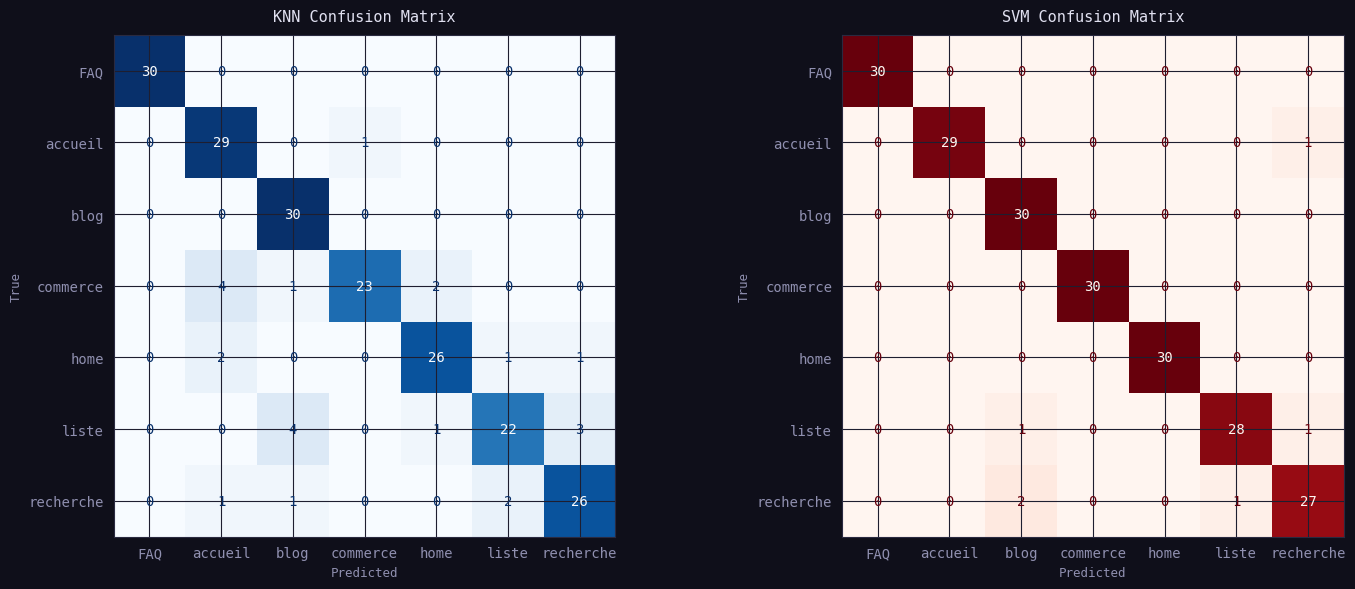

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, preds), cmap_color in zip(
    axes,
    [('KNN', knn_pred), ('SVM', svm_pred)],
    ['Blues', 'Reds']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap=cmap_color, colorbar=False)
    ax.set_title(f'{name} Confusion Matrix', fontsize=11, pad=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Class F1 Score Comparison

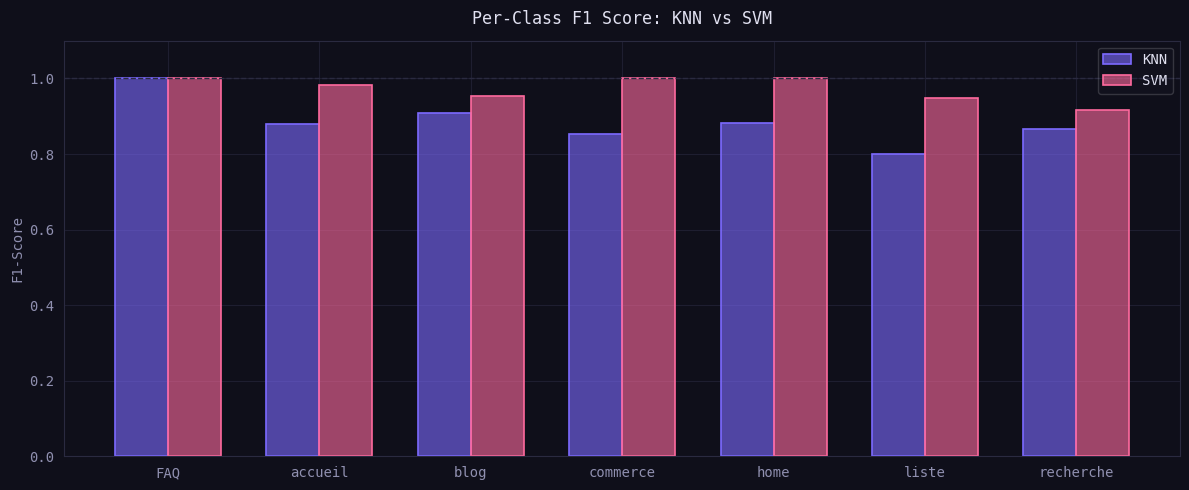

In [34]:
knn_report = classification_report(y_test, knn_pred, target_names=CLASSES, output_dict=True)
svm_report = classification_report(y_test, svm_pred, target_names=CLASSES, output_dict=True)

knn_f1 = [knn_report[c]['f1-score'] for c in CLASSES]
svm_f1 = [svm_report[c]['f1-score'] for c in CLASSES]

x = np.arange(len(CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, knn_f1, w, label='KNN', color='#7c6aff99', edgecolor='#7c6aff', linewidth=1.2)
ax.bar(x + w/2, svm_f1, w, label='SVM', color='#ff6a9e99', edgecolor='#ff6a9e', linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1 Score: KNN vs SVM', fontsize=12, pad=12)
ax.legend(fontsize=10, framealpha=0.2, facecolor='#1a1a2e')
ax.axhline(1.0, color='#2a2a40', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SVM Coefficients - Most Discriminative Terms

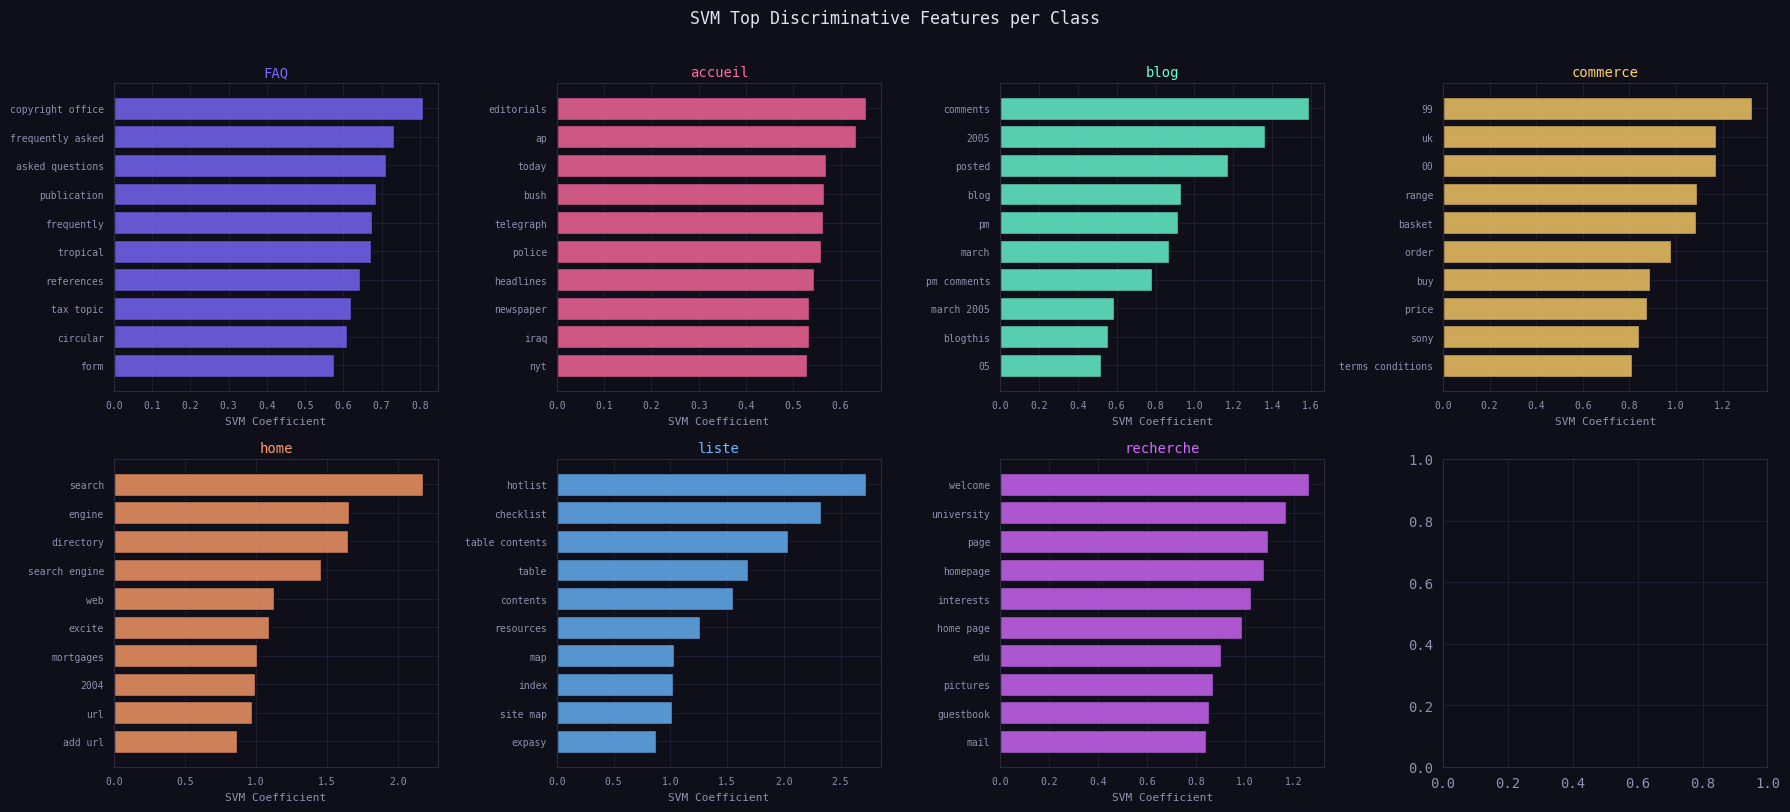

In [37]:
with open(f'{MODELS_DIR}/tfidf.pkl', 'rb') as f:
    tfidf = pickle.load(f)
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, (cls, color) in enumerate(zip(CLASSES, PALETTE)):
    coef = svm.coef_[i]
    top_pos = coef.argsort()[::-1][:10]
    axes[i].barh([feature_names[j] for j in top_pos][::-1],
                  coef[top_pos][::-1], color=color+'cc', edgecolor='#0f0f1a')
    axes[i].set_title(f'{cls}', fontsize=10, color=color, pad=5)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('SVM Coefficient', fontsize=8)

plt.suptitle('SVM Top Discriminative Features per Class', fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_svm_coef.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Trained Models

In [38]:
with open(f'{MODELS_DIR}/knn.pkl', 'wb') as f: pickle.dump(knn, f)
with open(f'{MODELS_DIR}/svm.pkl', 'wb') as f: pickle.dump(svm, f)
print('Models saved.')

# Save summary results for Streamlit app
import json
summary = {
    'knn_acc': round(knn_acc, 4),
    'svm_acc': round(svm_acc, 4),
    'knn_report': knn_report,
    'svm_report': svm_report,
    'knn_cm': confusion_matrix(y_test, knn_pred).tolist(),
    'svm_cm': confusion_matrix(y_test, svm_pred).tolist(),
    'classes': CLASSES
}
with open(f'{DATA_DIR}/model_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Results saved to model_results.json')

Models saved.
Results saved to model_results.json


## Summary

| Model | Accuracy | Macro F1 | Notes |
|---|---|---|---|
| KNN (k=5, cosine) | 83.3% | ~0.83 | Dense LSA + structural features |
| LinearSVC (C=5) | 97.1% | ~0.97 | Sparse TF-IDF, bigrams |

**Key insights:**
- SVM significantly outperforms KNN, improving accuracy by ~14 percentage points and delivering consistently higher F1 scores across classes.
- TF-IDF with bigrams provides strong discriminative signals, allowing the SVM to separate page types effectively without dimensionality reduction.
- LSA helps KNN by producing dense semantic vectors, but the compression loses some keyword-level information useful for classification.
- Certain classes (e.g., `FAQ`) are trivially separable, while others (`liste`, `recherche`) are more ambiguous due to overlapping vocabulary.
- Overall conclusion: sparse lexical features combined with a linear classifier are better suited for this text classification task than distance-based methods on reduced semantic embeddings.